# Equity Classification: Fundamental Stock Selection Model
**Machine Learning Pipeline**
The objective is to build a professional machine learning pipeline that predicts whether a stock will outperform the benchmark index (Target_Investable = 1). Priority to minimizing **False Positives** due to the higher cost of financial loss compared to opportunity loss (False Negatives).

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Loading the engineered dataset from Assignment 3
df = pd.read_csv(r'../Assignment 3/engineered_features.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (999, 42)


,Company Name,Industry group,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",Interest expenses,Depreciation,Total tax provision,...,Return_on_Capital_Employed_ROCE,Return_on_Assets_ROA,Debt_to_Equity_Ratio,Interest_Coverage_Ratio,Total_Asset_Turnover_Ratio,Working_Capital_Turnover_Ratio,Price_to_Earnings_P_E_Ratio,Enterprise_Value_to_Sales_EV_to_Sales,Market_Capitalization_to_Sales,EPS_Yield
0,3M India Ltd.,"Plastic furniture, floorings & miscellaneous i...",943.41,932.22,-12.09,818.55,562.38,0.56,13.88,38.46,...,0.006098,0.004530,-0.045337,271.053571,0.037451,7.466122,100.407669,26.701462,27.969510,0.009959
1,A B B India Ltd.,"Generators, transformers & switchgears",2496.92,2426.91,-12.97,2178.04,1475.34,7.24,26.82,94.32,...,0.007176,0.005377,-0.052023,56.280387,0.042742,7.610731,173.157253,23.396406,24.680339,0.005775
2,A C C Ltd.,Cement,4577.66,4536.97,-118.56,4348.65,1169.52,18.83,171.56,39.04,...,0.008198,0.003660,-0.183884,13.139671,0.150323,19.811231,47.052188,6.652346,8.151230,0.021253
3,A D F Foods Ltd.,Processed foods,102.34,99.77,-3.64,79.48,38.81,0.16,1.44,7.48,...,0.016942,0.012123,-0.054383,167.875000,0.062929,4.364392,8.903436,15.891033,16.804935,0.112316
4,A G I Greenpac Ltd.,Glass & glassware,570.40,567.30,12.31,529.48,199.24,13.13,30.25,16.04,...,0.025542,0.016456,0.529349,6.275704,0.175847,13.863636,29.291147,5.686759,3.718417,0.034140


## 7 Data Preprocessing

**Note from Assignment 3:** We observed that financial ratios and valuation metrics are stronger predictors than raw size metrics. Missing values in engineered features were imputed with industry medians, and outliers were treated using 1st-99th percentile winsorization. We will verify these and apply further preprocessing as required.

In [24]:
# Separate features (X) from the target variable (y). We will drop identifier columns and future-looking features (like `Forward_Return`, `Closing Price.1`, `Company Name`).
# Defining identifiers and target
identifiers = ['Company Name', 'Closing Price.1', 'Forward_Return']
target = 'Target_Investable'

# Drop identifiers and target from X
X = df.drop(columns=identifiers + [target])
y = df[target]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (999, 38)
Target (y) shape: (999,)


In [25]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Features ({len(numerical_features)}): {numerical_features[:5]}...")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Numerical Features (37): ['Total income from continuing operations', 'Net sales', 'Change in stock', 'Total expenses', 'Raw materials, stocks, spares, purchase of finished goods']...
Categorical Features (1): ['Industry group']


In [26]:
# Check for missing values in the dataset
missing_counts = X.isnull().sum()
print(missing_counts)
missing_features = missing_counts[missing_counts > 0]
print("Features with missing values:")
print(missing_features)

Industry group                                                             0
Total income from continuing operations                                    0
Net sales                                                                  0
Change in stock                                                            0
Total expenses                                                             0
Raw materials, stocks, spares, purchase of finished goods                  0
Interest expenses                                                          0
Depreciation                                                               0
Total tax provision                                                        0
Net Profit/(Loss) for the period from continuing operations (after tax)    0
Reported Profit after tax                                                  0
PBT                                                                        0
PBDT                                                                       0

#### Log Transformation
**Purpose:** Machine learning models (especially linear ones) benefit from normally distributed features. We will identify highly right-skewed, strictly positive features and apply a `log1p()` transformation.
**Why log1p?** It handles zeros gracefully by adding 1 before the log transformation. Negative values, already symmetric features and categorical variables will not be transformed.

Highly skewed positive features to log-transform: ['Total income from continuing operations', 'Net sales', 'Total expenses', 'Raw materials, stocks, spares, purchase of finished goods', 'Interest expenses', 'Depreciation', 'Closing Price', 'Shares Outstanding', 'Market Capitalisation', 'P/E', 'Number of Transactions', 'Market_Capitalization_to_Sales']


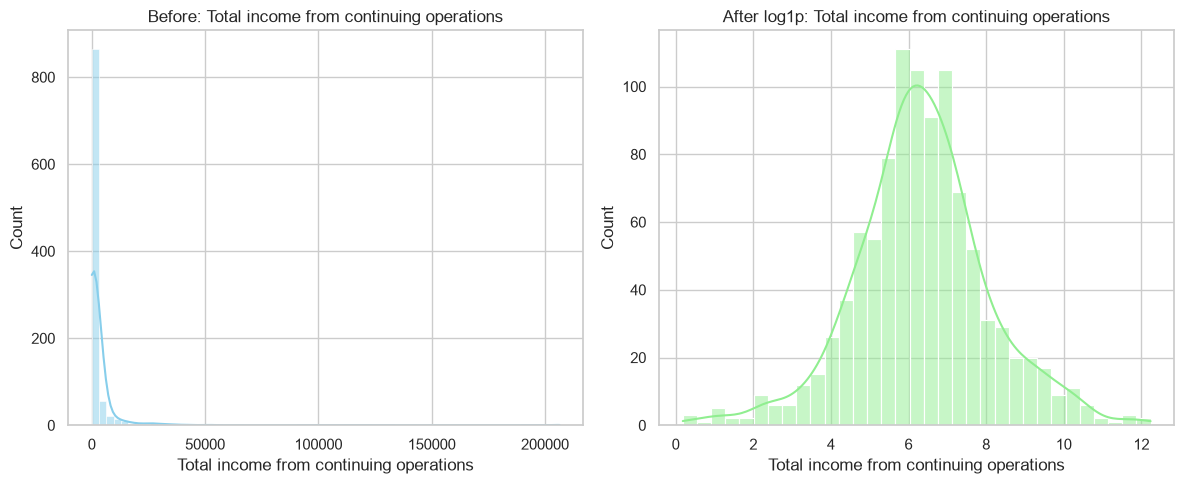

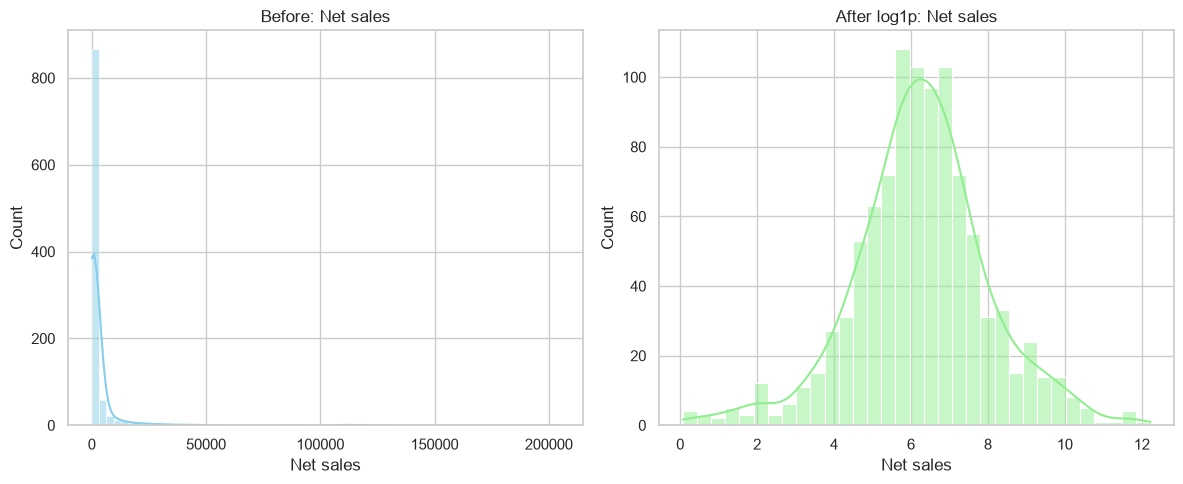

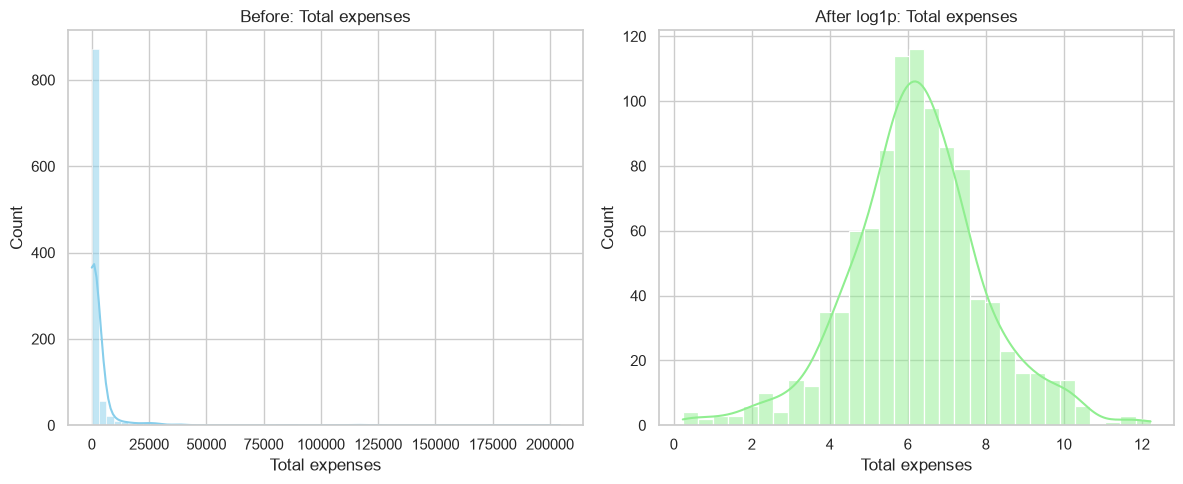

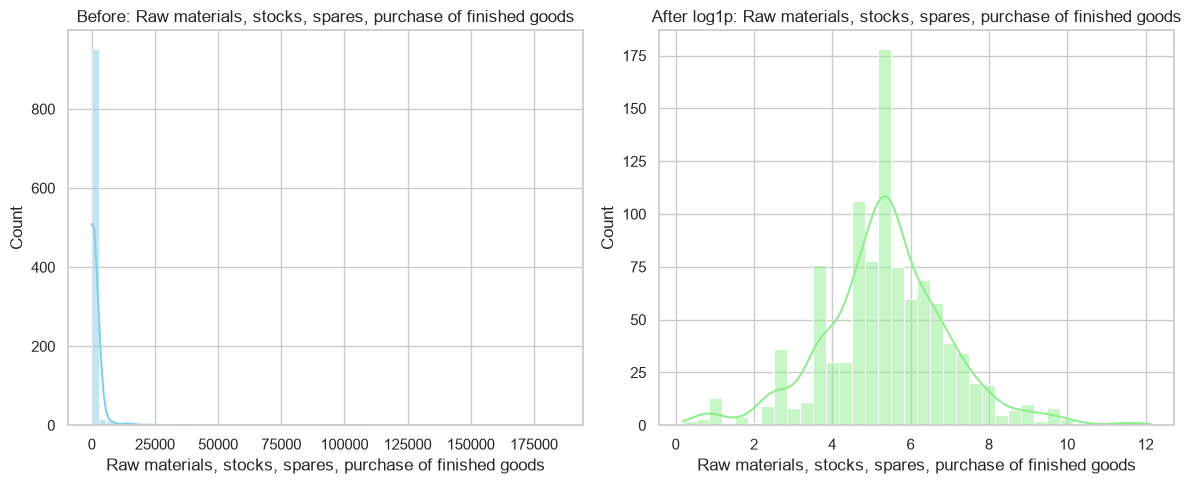

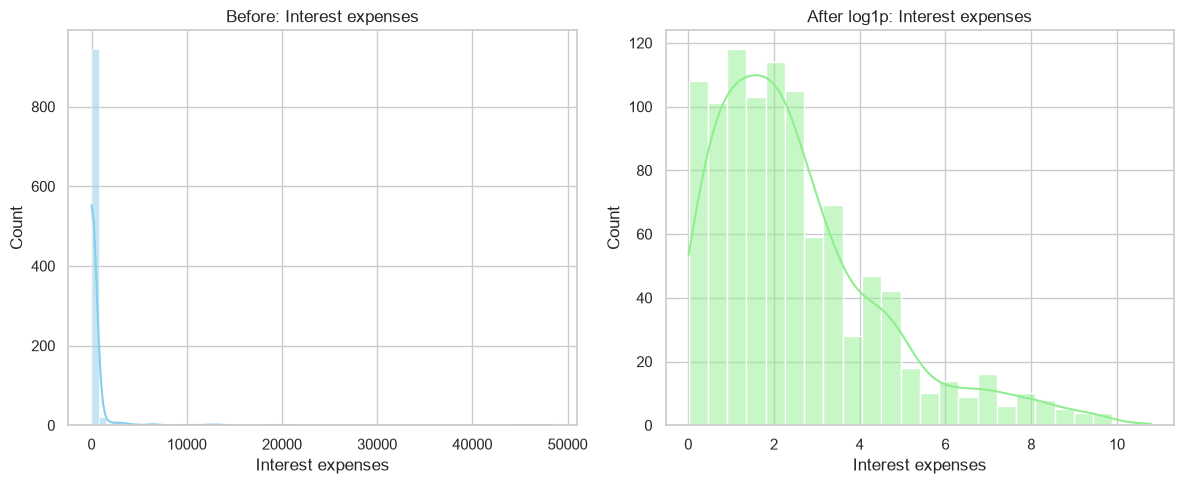

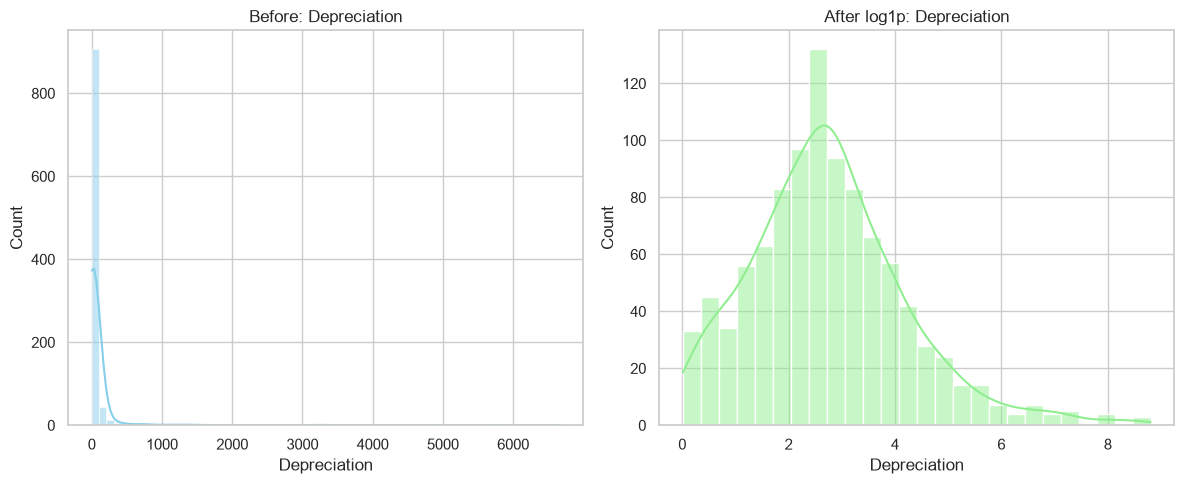

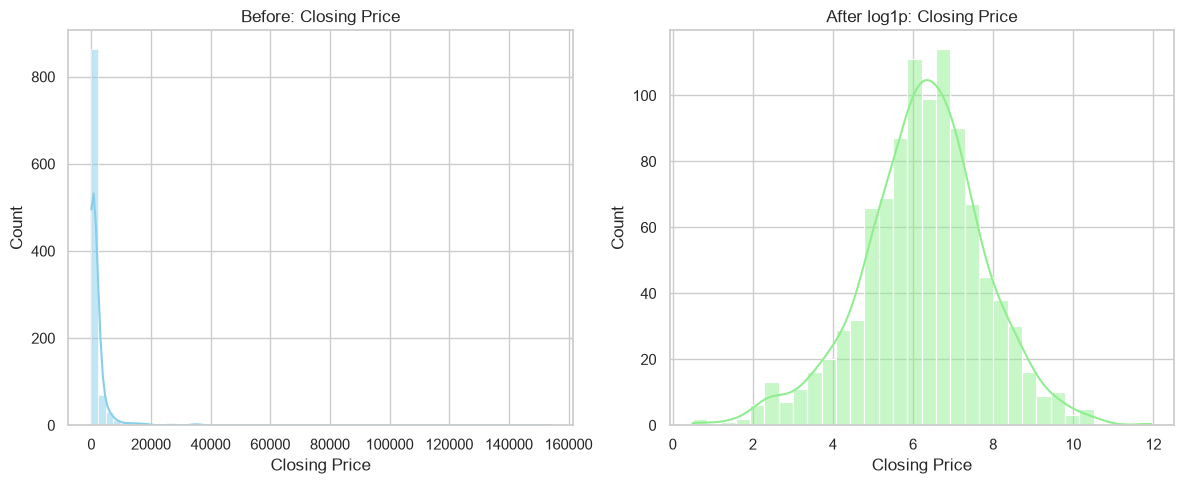

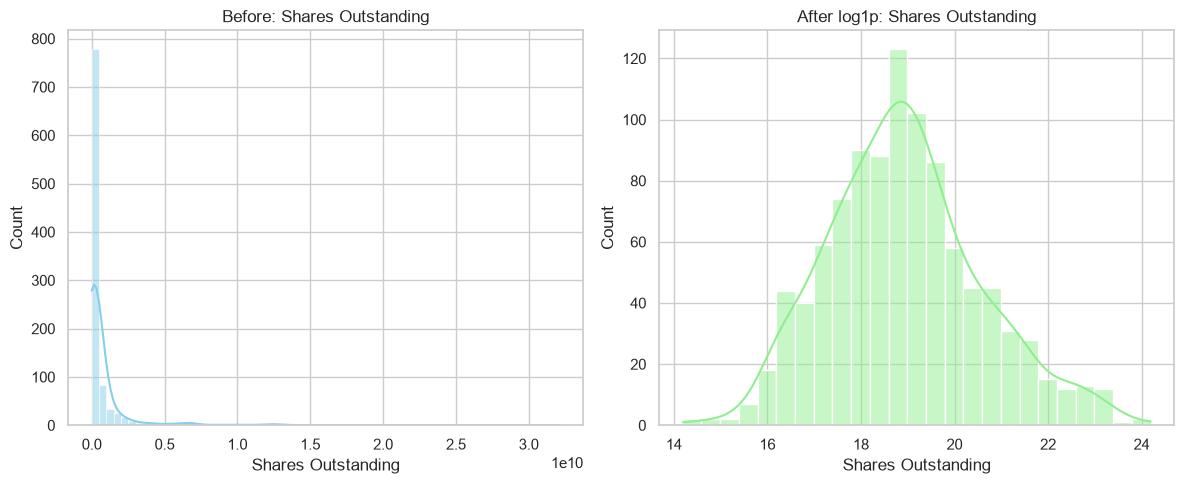

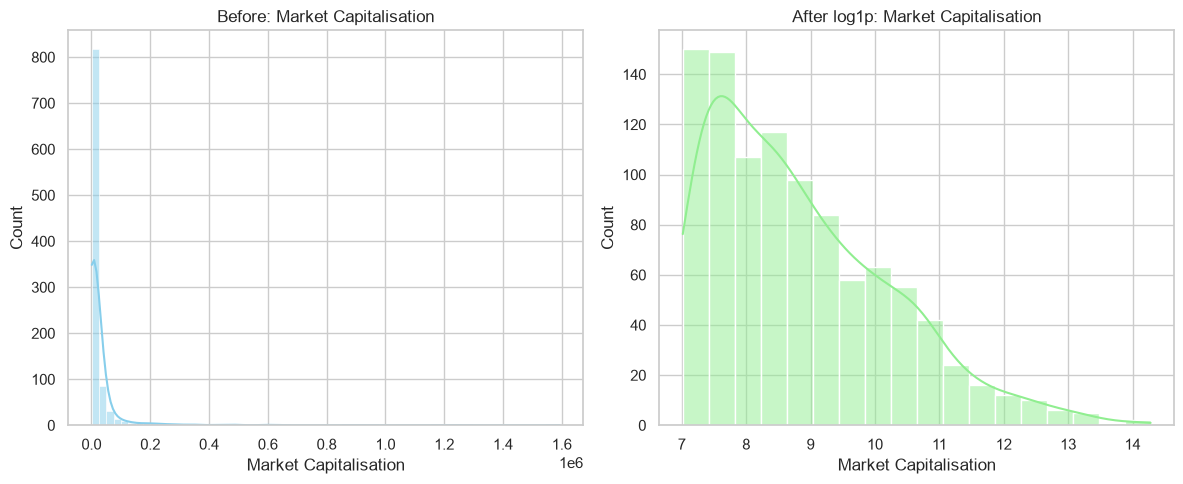

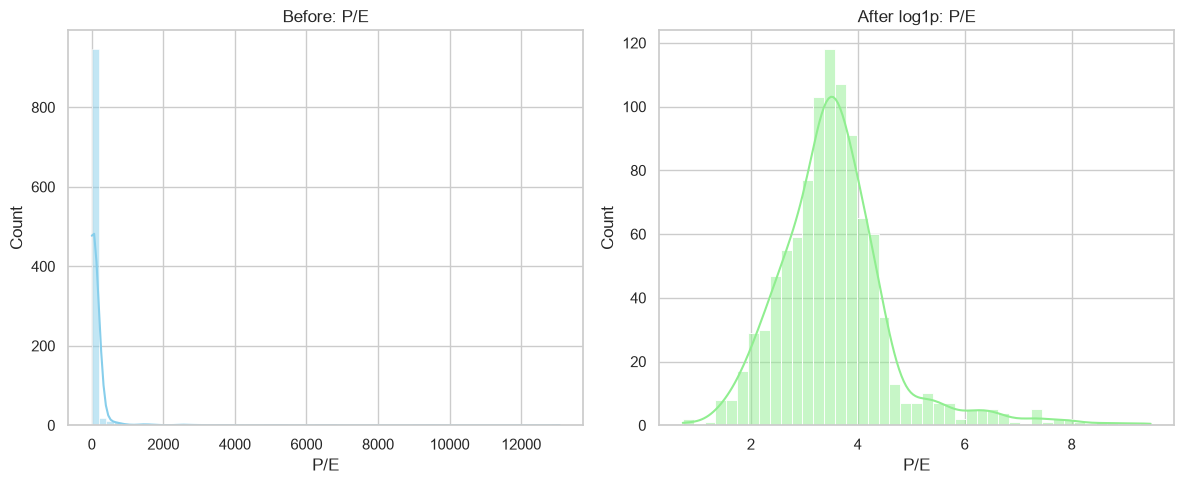

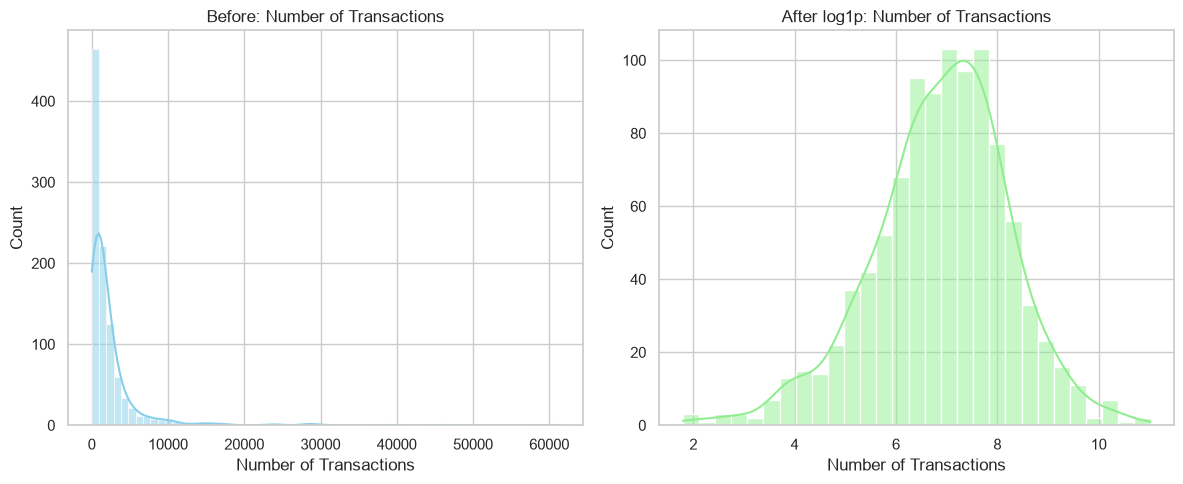

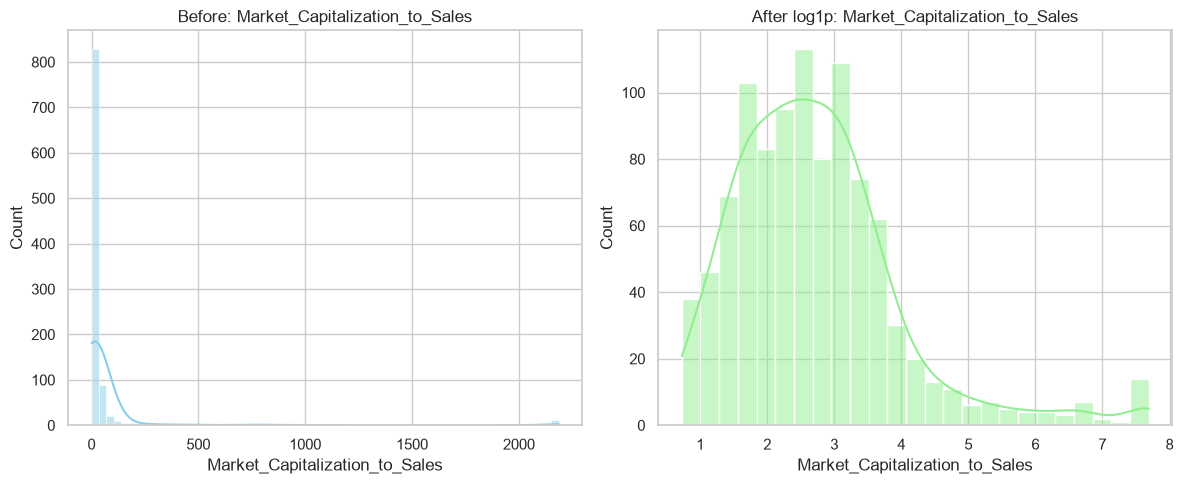

In [27]:
# Calculate skewness for strictly positive features
skewness = X[numerical_features].skew()
positive_features = X[numerical_features].columns[(X[numerical_features] >= 0).all()]
highly_skewed = skewness[(skewness > 1) & (skewness.index.isin(positive_features))].index.tolist()

print(f"Highly skewed positive features to log-transform: {highly_skewed}")

# Visualization Before vs After
for feature in highly_skewed:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(X[feature], kde=True, color='skyblue')
    plt.title(f'Before: {feature}')
    
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(X[feature]), kde=True, color='lightgreen')
    plt.title(f'After log1p: {feature}')
    
    plt.tight_layout()
    plt.show()

# Apply log1p transformation to these features
for col in highly_skewed:
    X[col] = np.log1p(X[col])

**Interpretation:**
Highly right-skewed positive features were transformed using log1p() to reduce skewness and improve model performance. Features containing negative values were retained in their original scale to preserve information and avoid invalid logarithmic transformations.

#### Encoding
Convert categorical variables into numeric formats suitable for ML algorithms. 
**Method:**  `Industry group` as categorical feature. Since it has high cardinality (132 unique industries),using **Target Encoding**, which replaces each category with the average target value for that category.

In [28]:
import category_encoders as ce

if 'Industry group' in categorical_features:
    target_encoder = ce.TargetEncoder(cols=['Industry group'])
    # temporary encoding here for Feature Selection, 
    # rigorous encoding will happen within the Pipeline later.
    X['Industry group'] = target_encoder.fit_transform(X['Industry group'], y)
    print("Applied Target Encoding to 'Industry group'.")
else:
    print("No categorical variables remain.")

Applied Target Encoding to 'Industry group'.


#### Feature Selection

- **Scaling:** Standardize features to have a mean of 0 and variance of 1. Crucial for distance-based and gradient-based models (Logistic Regression, SVM, KNN), but not needed for tree-based models (Random Forest, XGBoost).
- **Feature Selection:** Remove redundant (highly correlated) features and select the most important ones to reduce overfitting and improve interpretability. Using a Correlation Filter followed by SelectFromModel (Feature Importance).

We will combine these into a `Pipeline` during the Model Building.

In [32]:
display(X.head())

,Industry group,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",Interest expenses,Depreciation,Total tax provision,Net Profit/(Loss) for the period from continuing operations (after tax),...,Return_on_Capital_Employed_ROCE,Return_on_Assets_ROA,Debt_to_Equity_Ratio,Interest_Coverage_Ratio,Total_Asset_Turnover_Ratio,Working_Capital_Turnover_Ratio,Price_to_Earnings_P_E_Ratio,Enterprise_Value_to_Sales_EV_to_Sales,Market_Capitalization_to_Sales,EPS_Yield
0,0.322030,6.850560,6.838641,-12.09,6.708755,6.333954,0.444686,2.700018,38.46,112.77,...,0.006098,0.004530,-0.045337,271.053571,0.037451,7.466122,100.407669,26.701462,3.366244,0.009959
1,0.216172,7.823214,7.794786,-12.97,7.686640,7.297321,2.109000,3.325755,94.32,305.91,...,0.007176,0.005377,-0.052023,56.280387,0.042742,7.610731,173.157253,23.396406,3.245726,0.005775
2,0.186613,8.429162,8.420235,-118.56,8.377851,7.065203,2.987196,5.150745,39.04,110.45,...,0.008198,0.003660,-0.183884,13.139671,0.150323,19.811231,47.052188,6.652346,2.213888,0.021253
3,0.331909,4.638025,4.612841,-3.64,4.388009,3.684118,0.148420,0.891998,7.48,19.22,...,0.016942,0.012123,-0.054383,167.875000,0.062929,4.364392,8.903436,15.891033,2.879476,0.112316
4,0.237833,6.348089,6.342649,12.31,6.273782,5.299517,2.648300,3.442019,16.04,53.23,...,0.025542,0.016456,0.529349,6.275704,0.175847,13.863636,29.291147,5.686759,1.551473,0.034140


In [36]:
corr_matrix = X.corr(numeric_only=True)
corr_matrix.to_csv("correlation_matrix.csv", index=True)

In [38]:
to_drop_corr = [
    "Net sales",
    "Total expenses",
    "PBT",
    "PBDT",
    "PBIT net of P&E"
]

X_filtered = X.drop(columns=to_drop_corr)
print(f"Remaining features: {X_filtered.shape[1]}")

# Feature Selection: Random Forest Feature Importance (SelectFromModel)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_filtered, y)

sfm = SelectFromModel(
    rf_selector,
    prefit=True,
    threshold="median"
)

selected_features = X_filtered.columns[sfm.get_support()]
X_final = X_filtered[selected_features]
print(X_final.head())


Remaining features: 33
   Industry group   PBDIT  Earnings per share before extraordinary item  \
0        0.322030  165.67                                        100.11   
1        0.216172  433.51                                         14.41   
2        0.186613  339.88                                          5.88   
3        0.331909   28.30                                          1.75   
4        0.237833  112.46                                          8.21   

   Closing Price  Shares Outstanding         EPS       P/E  Industry P/E  \
0      10.458290           16.237217  346.895314  4.215415         52.52   
1       8.551942           19.171665   29.890749  4.559783         78.35   
2       7.469455           19.050820   37.249065  3.986570         48.83   
3       5.349248           16.905312   23.524626  3.509640         67.56   
4       6.583202           17.985231   24.643965  2.655382         33.34   

   Return_on_Equity_ROE  Return_on_Capital_Employed_ROCE  \
0        

**Interpretation:**
1. **Correlation Filter:** A Pearson correlation threshold of 0.90 was used to identify redundant features. Highly correlated raw financial variables were removed while retaining representative variables and engineered financial ratios.
2. **Feature Importance:** Feature importance from a Random Forest model was then used to further select the most informative predictors for the final classification model.

### 8. Train-Test Split
Spliting the data into training and testing sets.
Using **Stratified Train-Test Split** because the dataset contains one observation per company (cross-sectional) and has a class imbalance (as observed in Assignment 3). Stratification ensures the train and test sets have the same proportion of Investable vs Non-Investable companies.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train set class distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set class distribution:\n{y_test.value_counts(normalize=True)}")

Train set class distribution:
Target_Investable
0    0.718398
1    0.281602
Name: proportion, dtype: float64
Test set class distribution:
Target_Investable
0    0.72
1    0.28
Name: proportion, dtype: float64


### 9. Cross Validation
To robustly evaluate model performance during training and avoid overfitting to a specific validation set.
**Method:** We implement **Stratified 5-Fold Cross Validation**. 
Stratified KFold guarantees that each fold maintains the original class imbalance ratio, providing a more reliable estimate of model performance.

In [40]:
from sklearn.model_selection import StratifiedKFold

# Define the CV strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 10. Model Building
Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), and XGBoost.
- For Logistic Regression and SVM, the pipeline includes `StandardScaler`.
- For Tree-based models (Decision Tree, Random Forest, XGBoost), no scaling is applied.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate

# Define models
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(probability=True, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
    ])
}

# Evaluate models using Cross-Validation
results = []
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for name, pipeline in models.items():
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv_strategy, scoring=scoring, n_jobs=-1)
    results.append({
        'Model': name,
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'F1 Score': cv_results['test_f1'].mean(),
        'ROC-AUC': cv_results['test_roc_auc'].mean()
    })

baseline_results = pd.DataFrame(results).sort_values(by='Precision', ascending=False)
display(baseline_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,SVM,0.867351,0.874498,0.613333,0.719914,0.917158
4,XGBoost,0.921179,0.874347,0.840000,0.856541,0.967481
3,Random Forest,0.889890,0.858850,0.728889,0.787203,0.952214
0,Logistic Regression,0.849843,0.787227,0.640000,0.702732,0.900910
2,Decision Tree,0.853624,0.738483,0.746667,0.741306,0.821083


**Interpretation:**
Since False Positives are more costly, **Precision** and **ROC-AUC** are the primary evaluation metrics. Among the baseline models, XGBoost achieved the best overall performance with the highest Accuracy (92.1%), Recall (84.0%), F1 Score (85.7%), and ROC-AUC (96.7%)

### 11. Model Evaluation
Evaluate all models on the unseen Test set to verify their generalization capabilities. Focus on Precision, False Positive Rate, and business implications.

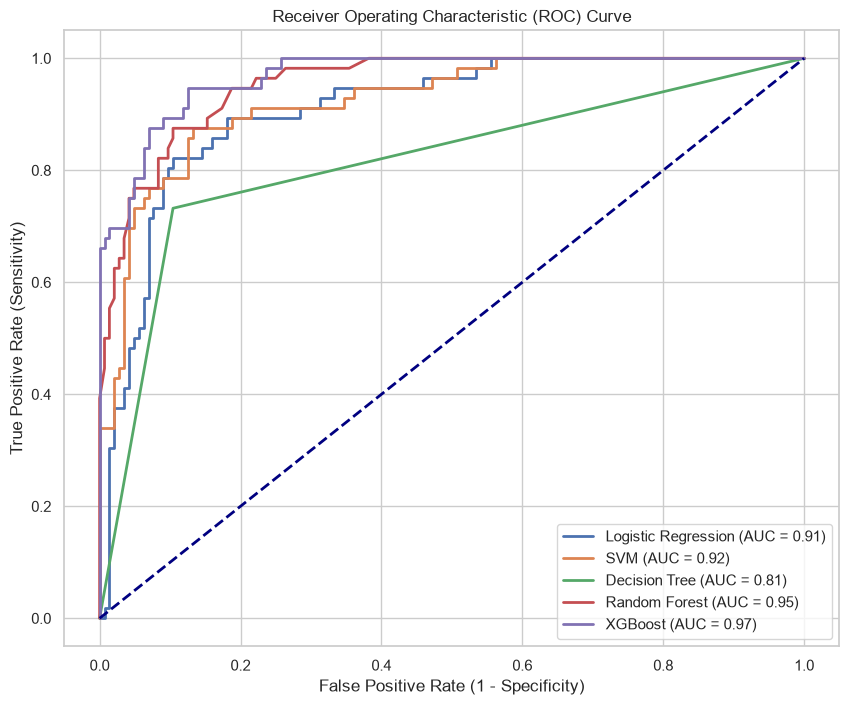

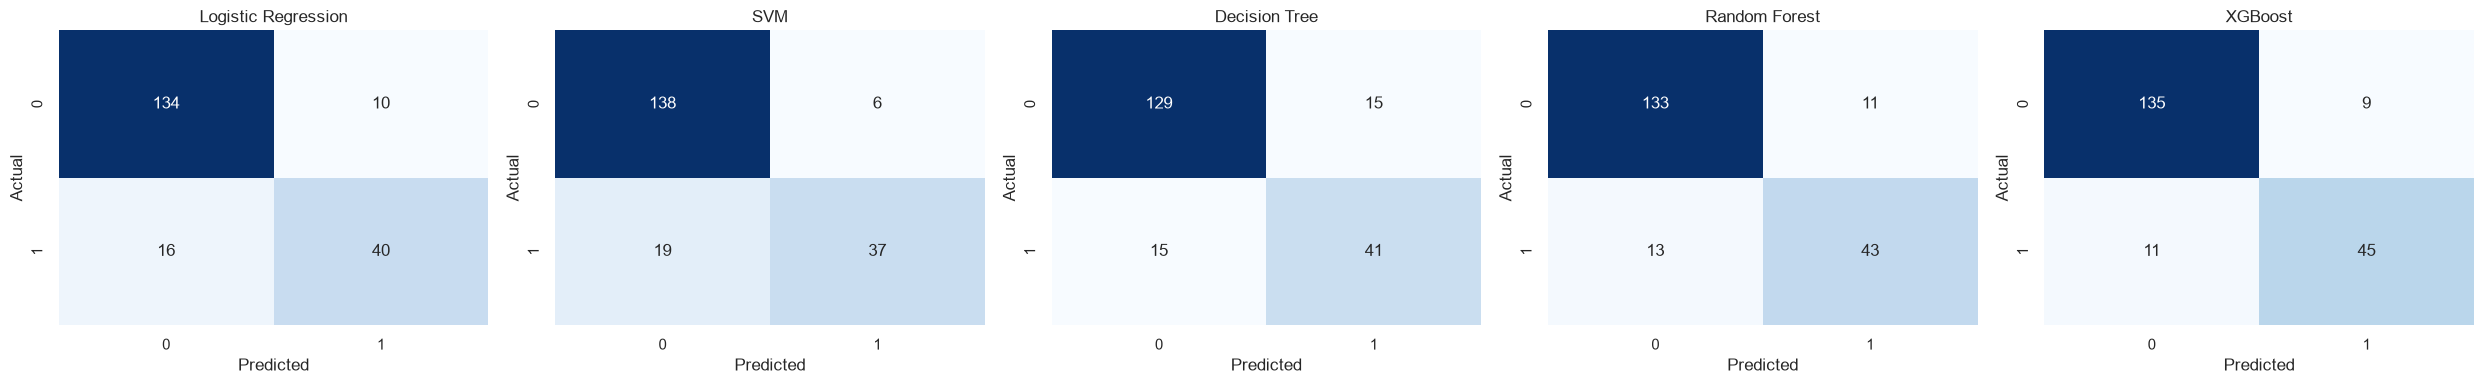

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

test_results = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    test_results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba
    }

# Plot ROC Curves for all models
plt.figure(figsize=(10, 8))
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Display Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for idx, (name, res) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Interpretation:**
**XGBoost** is selected as the best baseline model. Its balanced performance makes it the most suitable model for the equity classification task and the best candidate for hyperparameter tuning.

### 12. Hyperparameter Tuning
optimize hyperparameters using `RandomizedSearchCV` to extract maximum performance without excessive computational cost.

In [44]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

best_model_name = 'XGBoost'
print(f"Selected Best Model for Tuning: {best_model_name}")

# Define parameter grid
param_dist = {
    'classifier__n_estimators': stats.randint(100, 500),
    'classifier__learning_rate': stats.uniform(0.01, 0.2),
    'classifier__max_depth': stats.randint(3, 10),
    'classifier__subsample': stats.uniform(0.6, 0.4),
    'classifier__colsample_bytree': stats.uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    models['XGBoost'], 
    param_distributions=param_dist, 
    n_iter=20, 
    scoring='precision', # Optimizing for Precision
    cv=cv_strategy, 
    random_state=42, 
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation Precision: {random_search.best_score_:.4f}")

# Evaluate tuned model on Test Set
best_pipeline = random_search.best_estimator_
y_pred_tuned = best_pipeline.predict(X_test)

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Selected Best Model for Tuning: XGBoost
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'classifier__colsample_bytree': np.float64(0.7554709158757928), 'classifier__learning_rate': np.float64(0.06426980635477918), 'classifier__max_depth': 7, 'classifier__n_estimators': 379, 'classifier__subsample': np.float64(0.7427013306774357)}
Best Cross-Validation Precision: 0.9077

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       144
           1       0.82      0.84      0.83        56

    accuracy                           0.91       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.91      0.91      0.91       200



**Interpretation:**
Hyperparameter tuning improved the XGBoost model by optimizing the learning rate, restricting tree depth, number of estimators, subsampling and feature sampling, helping to improve generalization while reducing overfitting. 

The tuned model achieved a cross-validation Precision of 90.8% and maintained strong test performance with 91% Accuracy, 82% Precision, 84% Recall and an F1 Score of 83%. 

By optimizing Precision during hyperparameter tuning, the model becomes more conservative in identifying investable companies, reducing False Positives while maintaining good Recall. This aligns well with the business objective of minimizing incorrect investment recommendations.

### 13. Feature Importance & Explainability
Extracting the Tree Feature Importance from our tuned model to understand the financial reality behind the algorithm.

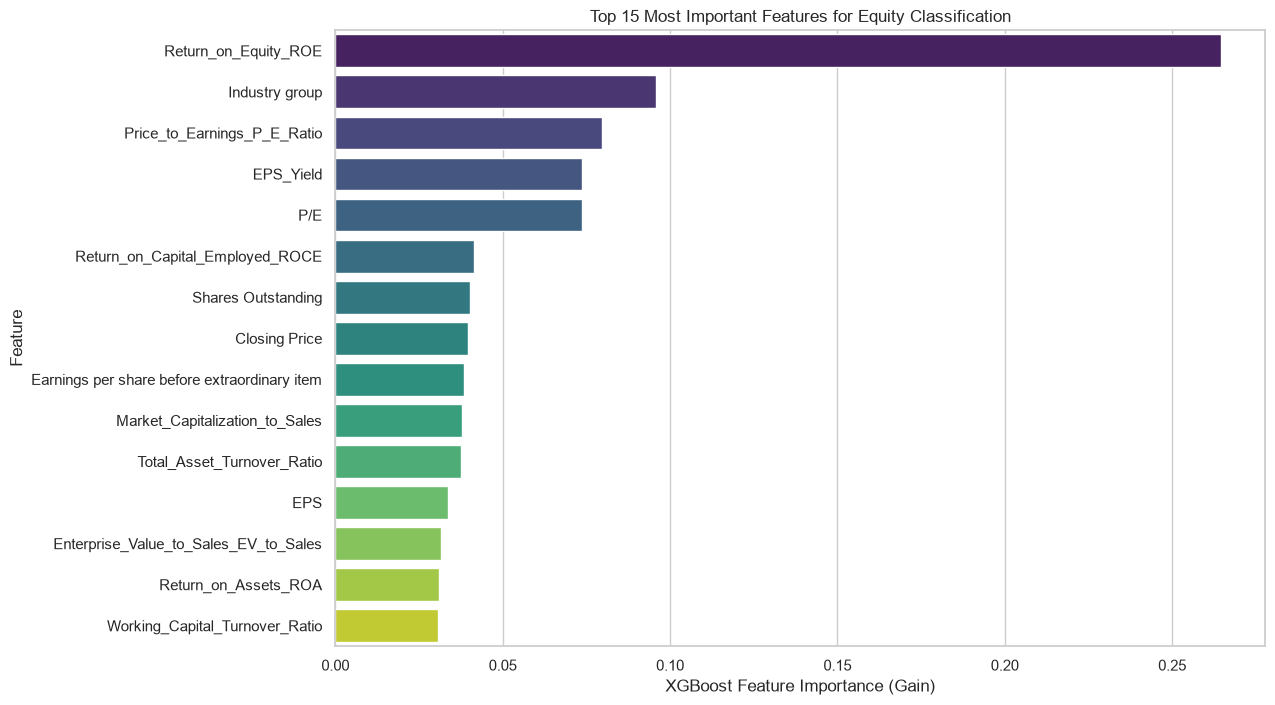

In [45]:
# Importances from the XGBoost Classifier
xgb_model = best_pipeline.named_steps['classifier']
importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Features for Equity Classification')
plt.xlabel('XGBoost Feature Importance (Gain)')
plt.ylabel('Feature')
plt.show()

**Interpretation:**
The feature importance analysis indicates that Return on Equity (ROE) is the most influential predictor, contributing significantly more than any other feature to the model's decisions. 

Valuation metrics such as Price-to-Earnings (P/E) Ratio, EPS Yield, and Market Capitalization-to-Sales, along with the Industry group, also play an important role, indicating that both company fundamentals and industry context influence investment decisions. Features such as ROCE, ROA, Asset Turnover, and EV-to-Sales provide additional information about profitability and operational efficiency, resulting in a balanced, financially meaningful model.

**Observation**
The high importance of the Industry group indicates that sector-specific characteristics contribute significantly to identifying investable companies, highlighting that investment opportunities vary across industries.